<a href="https://colab.research.google.com/github/sriramrangu/Machine-Learning-Practice/blob/main/CustomerChurnProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# Predict wheather will leave the company or not using Logistic Regression

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [52]:
customer = pd.read_csv("/content/customer_churn.csv")
customer

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# TASK to be performed:
- Data Exploration
- EDA
- Implement a model for classification using logistic regression
- Evaluate the accuracy
- Include Visualization wherever possible(optional)

In [53]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
customer.drop(columns=["customerID"],inplace=True)

In [55]:
customer.isnull().sum().sum()

np.int64(0)

In [56]:
customer.duplicated().sum()

np.int64(22)

In [57]:
customer.drop_duplicates(inplace=True)

In [58]:
customer.duplicated().sum()

np.int64(0)

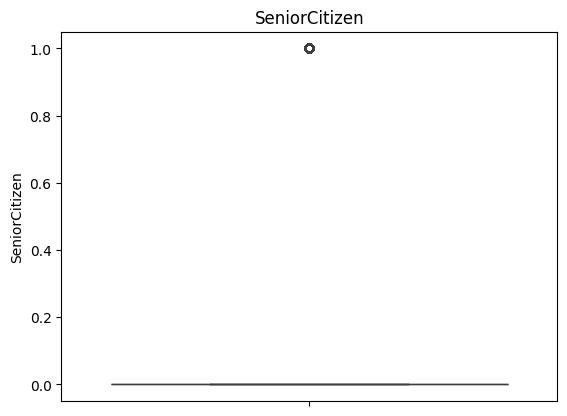

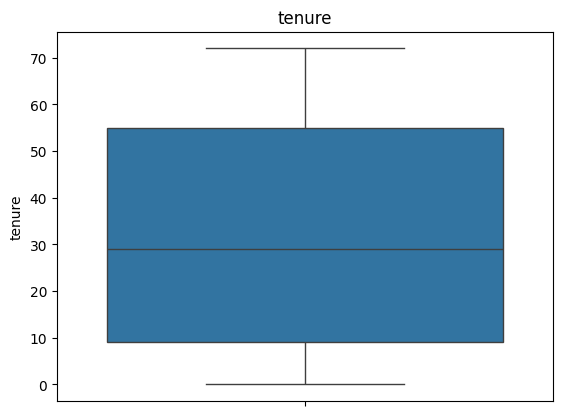

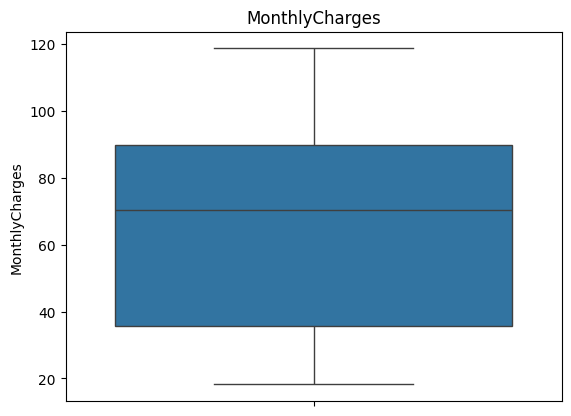

In [59]:
for col in customer.columns:
  if customer[col].dtype !=  'object':
    sns.boxplot(customer[col])
    plt.title(col)
    plt.show()

In [60]:
le = LabelEncoder()

for col in customer.columns:
  if customer[col].dtype == 'object':
    customer[col] = le.fit_transform(customer[col])

In [61]:
customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660,1


In [62]:
X = customer.iloc[:,:-1]
y = customer['Churn']

In [63]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


In [64]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100, train_size=0.8)

In [66]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
857,1,0,0,0,1,1,0,0,0,2,0,0,0,0,0,0,2,50.80,4235
4887,0,0,1,1,38,1,0,2,1,1,1,1,1,1,0,0,3,20.45,5924
6449,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,19.55,1485
5300,0,0,1,1,1,1,0,1,0,0,0,0,2,0,0,1,3,80.05,6014
1185,0,0,0,0,1,1,2,0,0,0,0,0,0,2,0,1,2,60.15,4912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0,0,1,1,45,1,2,2,1,1,1,1,1,1,1,1,1,25.90,397
3936,1,0,0,0,9,1,0,0,2,0,2,2,0,2,0,1,0,68.25,4755
5969,0,0,0,0,31,1,0,1,2,0,2,2,0,0,0,0,2,87.60,2368
6958,0,0,1,1,13,1,0,2,1,1,1,1,1,1,2,1,0,19.75,2111


In [67]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5768,1,0,1,0,44,1,0,1,0,0,0,0,2,2,1,1,0,90.65,3397
6605,1,1,0,0,66,1,2,1,0,2,2,2,2,2,1,0,1,110.90,5745
4538,0,0,0,0,3,1,0,1,0,0,0,2,0,2,0,0,2,85.80,2361
3822,0,0,1,1,6,1,2,1,0,2,2,0,2,0,0,1,3,94.05,4344
2060,1,0,1,1,71,1,2,0,2,2,2,2,2,2,2,0,2,90.35,5111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4922,0,0,1,1,61,1,2,0,2,2,0,0,0,0,0,0,2,59.80,3145
390,0,0,0,0,27,1,2,1,0,0,0,0,2,2,0,1,0,95.60,2243
1008,1,0,1,1,32,1,2,1,2,0,0,0,2,2,0,1,1,99.55,2785
4554,1,0,0,0,20,1,0,1,2,2,2,2,2,2,0,1,0,108.20,1836


In [68]:
lr = LogisticRegression()

In [69]:
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [70]:
y_pred = lr.predict(X_test)

In [71]:
accuracy_score(y_test, y_pred) * 100

78.932384341637

ValueError: x and y must be the same size

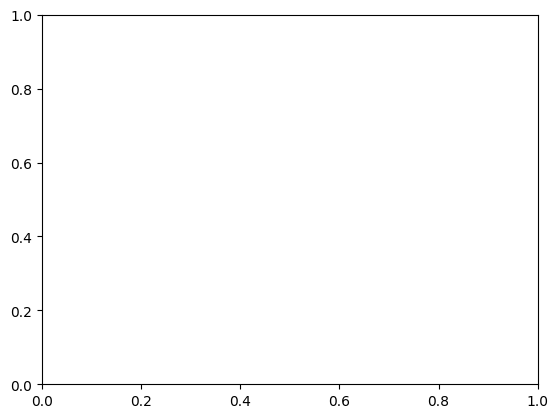

In [73]:
plt.scatter(X,y, color='blue')
plt.plot(X_test)
plt.show()